# Notebook 10 — Multi-Pair Portfolio with Equal Risk Contribution

**Adaptive Pair Trading | Ayush Arora (MQMS2404)**

---

## What this notebook does

Constructs a risk-diversified portfolio from **the pairs NB08 selected**
(`data/top_pairs.csv`, read directly — no hardcoded fallback):

1. **Kalman Filter** adaptive hedge ratio per pair
2. **Z-score signal** per pair — `config.rolling_zscore` (252/60)
3. **P&L as a return on deployed capital** — `config.pair_backtest`
   (gross exposure `price_A + |β|·price_B`), swept at **10 / 30 / 60 bps** round trip
4. **Cross-pair return correlation**
5. **Equal Risk Contribution (ERC)** weights
6. **Portfolio analytics** — Sharpe (full daily series), drawdown (guarded),
   diversification ratio

**These are in-sample, full-history (2015–2024) numbers** — a portfolio-construction
illustration. The out-of-sample test lives in NB09.

### What this pass fixed
The previous P&L divided spread changes by the mean spread level — no capital
base, unbounded, and `(1+pnl).cumprod()` crossed zero (Max DD printed as
−1.3e13 %). It is now a return on gross exposure, bounded below by −100 % and
asserted. Sharpe is over the full daily series (flat days included), not active
days only. Costs are a two-leg round-trip parameter, swept, not a single
one-way 10 bps charge.

### What is ERC?
Weights chosen so **every pair contributes the same share of portfolio
volatility**. For `n` pairs with covariance Σ:
```
min_w  Σᵢ (RC_i − 1/n)²   s.t.  Σᵢ wᵢ = 1,  PORT_MIN_WEIGHT ≤ wᵢ ≤ PORT_MAX_WEIGHT
where RC_i = wᵢ · (Σw)_i / √(wᵀΣw)
```

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
from scipy.optimize import minimize
import warnings
from config import (
    PRICES_FILE, TOP_PAIRS_FILE,
    ROLL_WINDOW, ROLL_MIN_PERIODS, rolling_zscore,
    ENTRY_Z, EXIT_Z,
    COST_BPS_ROUND_TRIP, COST_BPS_ROUND_TRIP_LEVELS,
    pair_backtest, sharpe_ratio, max_drawdown,
    KF_DELTA, KF_INIT_P, kalman_hedge,
    PORT_TOP_PAIRS, PORT_MAX_WEIGHT, PORT_MIN_WEIGHT,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
COST_LEVELS = list(COST_BPS_ROUND_TRIP_LEVELS)   # (10, 30, 60) bps round trip
BASE_COST   = COST_BPS_ROUND_TRIP                 # used for ERC weights / correlation
print('Libraries loaded. Cost levels (bps round trip):', COST_LEVELS,
      '| base', BASE_COST)

Libraries loaded. Cost levels (bps round trip): [10, 30, 60] | base 30


In [2]:
prices = pd.read_csv(PRICES_FILE, index_col=0, parse_dates=True)

# ── Top pairs come from NB08 — no silent fallback ─────────────────────────
# A silent fallback to a hardcoded list changes what the portfolio is measuring
# without telling anyone. Missing file => stop and point at NB08.
if not os.path.exists(TOP_PAIRS_FILE):
    raise FileNotFoundError(
        f'{TOP_PAIRS_FILE} not found. Run _08_Universe_Pair_Scan.ipynb first — '
        'it writes the ranked pair list that this portfolio is built from.'
    )

top_pairs_df = pd.read_csv(TOP_PAIRS_FILE, index_col=0)
top_pairs = [
    (a, b) for a, b in zip(top_pairs_df['Stock A'], top_pairs_df['Stock B'])
    if a in prices.columns and b in prices.columns
]
if not top_pairs:
    raise ValueError(f'No usable pairs in {TOP_PAIRS_FILE} (tickers not in {PRICES_FILE}).')

n_available = len(top_pairs)
top_pairs = top_pairs[:PORT_TOP_PAIRS]
print(f'Loaded {n_available} pair(s) from {TOP_PAIRS_FILE}; '
      f'using top {len(top_pairs)} (PORT_TOP_PAIRS={PORT_TOP_PAIRS}).')
if n_available < PORT_TOP_PAIRS:
    print(f'NOTE: only {n_available} pair(s) cleared NB08 — portfolio has fewer '
          f'names than the {PORT_TOP_PAIRS}-pair target.')

for a, b in top_pairs:
    print(f'  {a.replace(".NS",""):15s} / {b.replace(".NS","")}')

Loaded 3 pair(s) from data/top_pairs.csv; using top 3 (PORT_TOP_PAIRS=5).
NOTE: only 3 pair(s) cleared NB08 — portfolio has fewer names than the 5-pair target.
  DABUR           / HINDUNILVR
  GRASIM          / HINDALCO
  HINDALCO        / TATASTEEL


## Section 1: Kalman Filter Adaptive Hedge Ratio for Each Pair

`config.kalman_hedge` (the **same** filter NB07 uses) is applied to every pair
independently: state `[alpha_t, beta_t]` follows a random walk, observation noise
is estimated online, `delta = KF_DELTA`. It removes the static-beta look-ahead and
lets each relationship drift at its own pace — but see the turnover diagnostic
below for whether `KF_DELTA` is well-chosen for every pair.

In [3]:
# kalman_hedge is imported from config (shared with NB07 — one implementation).
# Signature: kalman_hedge(y, x, delta=KF_DELTA, init_p=KF_INIT_P)
#   returns (kf_alpha, kf_beta, kf_spread);  kf_spread = innovation e_t.
print('Using config.kalman_hedge  (delta =', KF_DELTA, ', init_p =', KF_INIT_P, ')')

Using config.kalman_hedge  (delta = 0.0001 , init_p = 10.0 )


In [4]:
pair_data = {}
for a, b in top_pairs:
    kf_alpha, kf_beta, kf_spread = kalman_hedge(prices[a], prices[b])
    # Static OLS beta on the full sample, for the turnover diagnostic
    ols = sm.OLS(prices[a], sm.add_constant(prices[b])).fit()
    beta_ols = ols.params.iloc[1]
    # Rolling Z-score on Kalman innovations — the ONE definition (config.rolling_zscore),
    # same 252/60 as NB03 and NB09. No look-ahead.
    kf_zscore = rolling_zscore(kf_spread)
    label = f'{a.replace(".NS","")} / {b.replace(".NS","")}'
    pair_data[label] = {
        'a': a, 'b': b,
        'kf_beta':   kf_beta,
        'kf_spread': kf_spread,
        'kf_zscore': kf_zscore,
        'beta_ols':  beta_ols,
    }
    warm = kf_beta.iloc[ROLL_MIN_PERIODS:]
    print(f'{label:22s}  KF beta [{kf_beta.min():.3f}, {kf_beta.max():.3f}]  '
          f'std {warm.std():.3f}  |  OLS beta {beta_ols:.3f}')

print(f'\nKalman filter estimated for {len(pair_data)} pairs.')

DABUR / HINDUNILVR      KF beta [0.199, 0.387]  std 0.046  |  OLS beta 0.180


GRASIM / HINDALCO       KF beta [3.126, 5.604]  std 0.505  |  OLS beta 3.456


HINDALCO / TATASTEEL    KF beta [3.401, 5.263]  std 0.435  |  OLS beta 3.948

Kalman filter estimated for 3 pairs.


### Diagnostic 3a — is `KF_DELTA` making β too jumpy?

DABUR/HINDUNILVR trades **98 times at 6.0% time in market** and is the only pair
whose Sharpe turns negative on cost (0.33 → −0.21 → −1.05 across 10/30/60 bps).
The other two pairs trade 19–24 times at 21–28% time in market. NB09 runs the
*same* DABUR/HINDUNILVR pair with a **static OLS β** and gets +0.36 @ 30 bps with
16 trades and 29% time in market. So the churn is specific to the Kalman hedge here.

This cell plots `kf_beta` vs the static OLS β for that pair and reports β
volatility for all three. `KF_DELTA` is **not** re-tuned — this is a diagnosis.

=== Kalman beta volatility by pair ===
                Pair  OLS beta  KF beta mean  KF beta std  KF beta CV  mean |dbeta/beta| per day %  KF range / OLS beta  innov lag-1 autocorr
  DABUR / HINDUNILVR     0.180         0.261        0.046       0.177                        0.957                 1.04                 0.023
   GRASIM / HINDALCO     3.456         4.135        0.505       0.122                        0.186                 0.72                 0.957
HINDALCO / TATASTEEL     3.948         4.393        0.435       0.099                        0.177                 0.47                 0.958


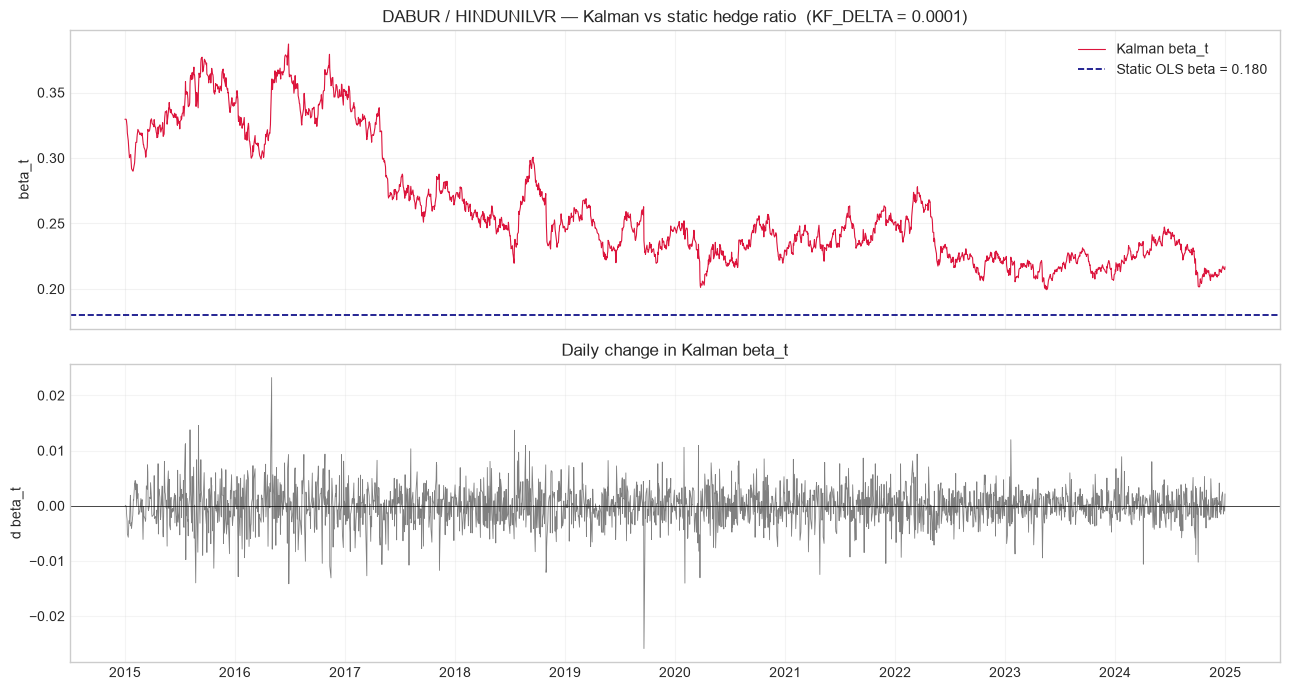


DABUR/HINDUNILVR beta CV 0.177 vs peers 0.099-0.122
DABUR/HINDUNILVR innovation lag-1 autocorr +0.023 vs peers +0.957 / +0.958  (near zero => innovation is white noise => rolling Z whipsaws across the bands)


In [5]:
# ── β volatility per pair (after the ROLL_MIN_PERIODS warm-up) ─────────────
beta_diag = []
for label, d in pair_data.items():
    beta = d['kf_beta'].iloc[ROLL_MIN_PERIODS:]
    dbeta = beta.diff().dropna()
    innov = d['kf_spread'].iloc[ROLL_MIN_PERIODS:]
    beta_diag.append({
        'Pair': label,
        'OLS beta': round(d['beta_ols'], 3),
        'KF beta mean': round(beta.mean(), 3),
        'KF beta std': round(beta.std(), 3),
        'KF beta CV': round(beta.std() / abs(beta.mean()), 3),           # std / |mean|
        'mean |dbeta/beta| per day %': round((dbeta / beta.shift(1)).abs().mean() * 100, 3),
        'KF range / OLS beta': round((beta.max() - beta.min()) / abs(d['beta_ols']), 2),
        'innov lag-1 autocorr': round(innov.autocorr(lag=1), 3),
    })
beta_diag = pd.DataFrame(beta_diag)
print('=== Kalman beta volatility by pair ===')
print(beta_diag.to_string(index=False))

# ── Plot: DABUR/HINDUNILVR kf_beta vs static OLS beta ─────────────────────
target = 'DABUR / HINDUNILVR'
d = pair_data[target]
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(d['kf_beta'], color='crimson', linewidth=0.8, label='Kalman beta_t')
axes[0].axhline(d['beta_ols'], color='navy', linestyle='--', linewidth=1.2,
                label=f'Static OLS beta = {d["beta_ols"]:.3f}')
axes[0].set_title(f'{target} — Kalman vs static hedge ratio  (KF_DELTA = {KF_DELTA})')
axes[0].set_ylabel('beta_t'); axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(d['kf_beta'].diff(), color='grey', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Daily change in Kalman beta_t')
axes[1].set_ylabel('d beta_t'); axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.savefig('kalman_beta_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Quantitative verdict inputs ──────────────────────────────────────────
cv = beta_diag.set_index('Pair')['KF beta CV']
ac = beta_diag.set_index('Pair')['innov lag-1 autocorr']
print(f"\nDABUR/HINDUNILVR beta CV {cv[target]:.3f} vs peers "
      f"{cv.drop(target).min():.3f}-{cv.drop(target).max():.3f}")
print(f"DABUR/HINDUNILVR innovation lag-1 autocorr {ac[target]:+.3f} vs peers "
      f"{ac.drop(target).min():+.3f} / {ac.drop(target).max():+.3f}  "
      "(near zero => innovation is white noise => rolling Z whipsaws across the bands)")

### Verdict: yes, `KF_DELTA = 1e-4` is too high for DABUR/HINDUNILVR

The numbers above (rerun to confirm; values as of the committed run):

| Pair | mean \|Δβ/β\| per day | KF β CV | innovation lag-1 autocorr | avg hold |
|------|--:|--:|--:|--:|
| DABUR / HINDUNILVR | **0.96%** | 0.177 | **+0.02** | **1.5 d** |
| GRASIM / HINDALCO | 0.19% | 0.122 | +0.96 | 28 d |
| HINDALCO / TATASTEEL | 0.18% | 0.099 | +0.96 | 27 d |

**Mechanism.** DABUR/HINDUNILVR's hedge ratio moves **~5× faster day-to-day** than the
two metals pairs. At that adaptation speed the filter absorbs ordinary short-term
noise in the DABUR–HUL price ratio into β_t, so the innovation e_t it produces is
**essentially white noise** (lag-1 autocorr +0.02, versus +0.96 for the metals
pairs). A white-noise series has a rolling Z-score that drifts across ±2σ and snaps
back within a day or two — hence 98 round trips at a 1.5-day average hold, which is
pure transaction-cost bleed and the reason the Sharpe collapses from +0.33 to −1.05
as cost rises.

The two metals pairs share the *same* `KF_DELTA` and are fine: their price
relationship genuinely drifts slowly, β_t stays smooth, and the innovation keeps
the autocorrelation the Z-score strategy needs. So this is not "1e-4 is wrong
everywhere" — it is "one global `KF_DELTA` cannot serve both a slowly-drifting
structural pair and a noisy one." **Not fixed here** (the brief says diagnose only);
a proper fix would set δ per pair, or gate the Kalman hedge behind a minimum
innovation-autocorrelation check.

## Section 2: Signal Generation & Individual Pair P&L

In [6]:
# ── Daily P&L per pair, as a return on deployed capital ───────────────────
# config.pair_backtest: long 1 unit A / short |kf_beta| units B, gross exposure
# price_A + |kf_beta|*price_B, P&L divided by exposure at entry. Kalman beta is a
# Series (lagged one day inside pair_backtest -> point-in-time). Full 2015-2024
# history: these are IN-SAMPLE portfolio-construction numbers, not OOS (NB09
# does the OOS test). Swept at 10 / 30 / 60 bps round trip.

def n_trades(pos):
    pos = pd.Series(pos)
    return int(((pos != 0) & (pos.shift(1).fillna(0) == 0)).sum())

ret_by_cost, bt_by_cost = {}, {}
for cost in COST_LEVELS:
    cols, bts = {}, {}
    for label, d in pair_data.items():
        bt = pair_backtest(prices[d['a']], prices[d['b']], d['kf_beta'],
                           d['kf_zscore'], cost_bps_round_trip=cost)
        cols[label] = bt['ret']
        bts[label]  = bt
    ret_by_cost[cost] = pd.DataFrame(cols)
    bt_by_cost[cost]  = bts

ret_df = ret_by_cost[BASE_COST]          # base case -> ERC weights, correlation
assert ret_df.to_numpy().min() > -1.0, 'daily return <= -100% — capital model broken'

for cost in COST_LEVELS:
    rd = ret_by_cost[cost]
    print(f'\n=== PER-PAIR (Kalman hedge) @ {cost} bps round trip ===')
    print(f'{"Pair":<24}{"AnnRet%":>9}{"Vol%":>8}{"Sharpe":>8}{"MaxDD%":>9}'
          f'{"TiM%":>7}{"Trades":>8}{"Hit%":>7}')
    for label in rd.columns:
        r   = rd[label]
        bt  = bt_by_cost[cost][label]
        act = r[r != 0]
        print(f'{label:<24}{r.mean()*252*100:>9.2f}{r.std()*np.sqrt(252)*100:>8.2f}'
              f'{sharpe_ratio(r):>8.3f}{max_drawdown(r):>9.2f}'
              f'{bt["in_market"].mean()*100:>7.1f}{n_trades(bt["pos"]):>8d}'
              f'{(act > 0).mean()*100:>7.1f}')


=== PER-PAIR (Kalman hedge) @ 10 bps round trip ===
Pair                      AnnRet%    Vol%  Sharpe   MaxDD%   TiM%  Trades   Hit%
DABUR / HINDUNILVR           1.24    3.79   0.326    -5.66    6.0      98   34.3
GRASIM / HINDALCO            2.85   10.37   0.275   -32.25   27.6      24   48.7
HINDALCO / TATASTEEL         1.48    7.87   0.187   -20.77   20.9      19   48.4

=== PER-PAIR (Kalman hedge) @ 30 bps round trip ===
Pair                      AnnRet%    Vol%  Sharpe   MaxDD%   TiM%  Trades   Hit%
DABUR / HINDUNILVR          -0.76    3.67  -0.208   -10.44    6.0      98   30.2
GRASIM / HINDALCO            2.36   10.34   0.228   -32.39   27.6      24   48.6
HINDALCO / TATASTEEL         1.09    7.83   0.139   -20.77   20.9      19   48.4

=== PER-PAIR (Kalman hedge) @ 60 bps round trip ===
Pair                      AnnRet%    Vol%  Sharpe   MaxDD%   TiM%  Trades   Hit%
DABUR / HINDUNILVR          -3.77    3.58  -1.053   -32.48    6.0      98   25.7
GRASIM / HINDALCO            1.

## Section 3: Pair P&L Correlation Analysis

The diversification benefit of a multi-pair portfolio depends critically on
how correlated the individual pair P&Ls are. If all pairs make and lose money
together, there is no diversification.

Ideally, cross-sector pairs should have near-zero P&L correlation.

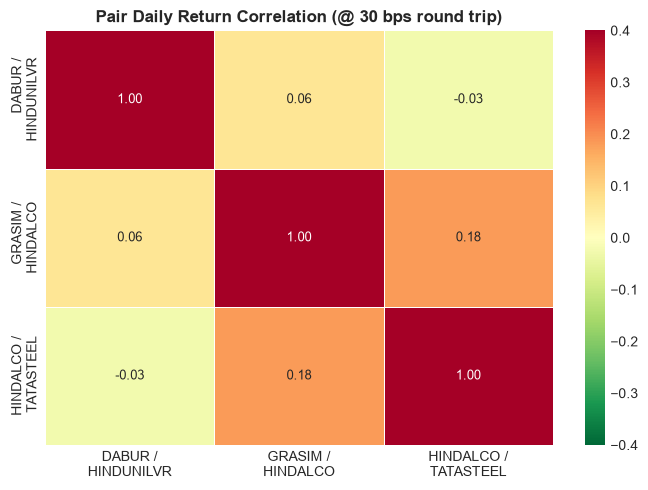

Average pairwise return correlation: 0.074
Diversification present: YES
Note: GRASIM/HINDALCO and HINDALCO/TATASTEEL share the HINDALCO leg with opposite sign, which suppresses (does not eliminate) their dependence.


In [7]:
pnl_corr = ret_df.corr()                       # daily return-on-capital correlation, base cost
short_labels = [c.replace('.NS', '').replace(' / ', ' /\n') for c in ret_df.columns]

fig, ax = plt.subplots(figsize=(max(7, len(ret_df.columns) + 2),
                                max(5, len(ret_df.columns))))
sns.heatmap(
    pnl_corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
    xticklabels=short_labels, yticklabels=short_labels,
    vmin=-0.4, vmax=0.4, center=0, ax=ax, linewidths=0.5,
    annot_kws={'size': 9}
)
ax.set_title(f'Pair Daily Return Correlation (@ {BASE_COST} bps round trip)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pair_pnl_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

avg_corr = pnl_corr.values[np.triu_indices_from(pnl_corr.values, k=1)].mean()
print(f'Average pairwise return correlation: {avg_corr:.3f}')
print(f'Diversification present: {"YES" if avg_corr < 0.4 else "LIMITED"}')
print('Note: GRASIM/HINDALCO and HINDALCO/TATASTEEL share the HINDALCO leg with '
      'opposite sign, which suppresses (does not eliminate) their dependence.')

## Section 4: Equal Risk Contribution (ERC) Portfolio Weights

ERC picks weights so every pair contributes the same fraction (1/n) of portfolio
volatility — no return forecasts, only the covariance matrix.

**Diagnostic 3b:** with the `PORT_MIN_WEIGHT` / `PORT_MAX_WEIGHT` box constraints,
exact ERC may be *infeasible* — if a pair's unconstrained ERC weight exceeds the
cap, its risk contribution cannot reach 1/n. The cell below solves ERC **twice**
(box-constrained, and unconstrained as the reference) and reports the risk-
contribution deviation for each, so a residual deviation is never mistaken for a
solver that failed to converge.

In [8]:
def risk_contribution_pct(w, cov):
    w = np.asarray(w, float)
    vol = np.sqrt(w @ cov @ w)
    rc = w * (cov @ w) / vol
    return rc / rc.sum()

def erc_weights(cov, min_w, max_w, restarts=8):
    """Equal Risk Contribution weights via SLSQP, multi-start. Returns
    (weights, converged_bool, objective, max_rc_deviation_from_1/n)."""
    n = len(cov)

    def objective(w):
        vol = np.sqrt(w @ cov @ w)
        rc  = w * (cov @ w) / (vol + 1e-12)
        return np.sum((rc - vol / n) ** 2)

    best = None
    rng = np.random.default_rng(0)
    starts = [np.ones(n) / n] + [rng.dirichlet(np.ones(n)) for _ in range(restarts)]
    for w0 in starts:
        w0 = np.clip(w0, min_w, max_w); w0 = w0 / w0.sum()
        res = minimize(objective, w0, method='SLSQP',
                       bounds=[(min_w, max_w)] * n,
                       constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
                       options={'ftol': 1e-16, 'maxiter': 10_000})
        if best is None or res.fun < best.fun:
            best = res
    w = best.x / best.x.sum()
    rc_pct = risk_contribution_pct(w, cov)
    max_dev = float(np.abs(rc_pct - 1 / n).max())
    return w, bool(best.success), float(best.fun), max_dev

n_pairs = ret_df.shape[1]
if n_pairs < 2:
    raise RuntimeError(f'Portfolio needs >= 2 pairs; NB08 delivered {n_pairs}.')

cov_matrix = ret_df.cov().values
vols_ann   = np.sqrt(np.diag(cov_matrix)) * np.sqrt(252)
inv_vol_w  = (1 / np.sqrt(np.diag(cov_matrix))); inv_vol_w /= inv_vol_w.sum()

# Box-constrained ERC (the weights the portfolio actually uses)
w_erc, ok_c, obj_c, dev_c = erc_weights(cov_matrix, PORT_MIN_WEIGHT, PORT_MAX_WEIGHT)
# Unconstrained ERC reference (weights in (0, 1), only sum-to-1)
w_ref, ok_u, obj_u, dev_u = erc_weights(cov_matrix, 1e-8, 1.0)
w_equal = np.ones(n_pairs) / n_pairs

print(f'Pair annualised vols %      : {np.round(vols_ann*100, 2)}')
print(f'Inverse-vol weights %       : {np.round(inv_vol_w*100, 1)}')
print(f'PORT_MAX_WEIGHT cap         : {PORT_MAX_WEIGHT:.0%}\n')

hdr = f'{"Pair":<24}{"Equal-wt":>10}{"ERC (capped)":>14}{"ERC (uncapped)":>16}'
print(hdr); print('-' * len(hdr))
for lbl, we, wc, wu in zip(ret_df.columns, w_equal, w_erc, w_ref):
    print(f'{lbl:<24}{we*100:>9.1f}%{wc*100:>13.1f}%{wu*100:>15.1f}%')

rc_c = risk_contribution_pct(w_erc, cov_matrix)
rc_u = risk_contribution_pct(w_ref, cov_matrix)
print(f'\n{"Risk contribution %":<24}{"":>10}{"":>14}{"":>16}')
for lbl, c, u in zip(ret_df.columns, rc_c, rc_u):
    print(f'{lbl:<24}{"":>10}{c*100:>13.1f}%{u*100:>15.1f}%')

print(f'\nCapped   ERC : solver_converged={ok_c}  objective={obj_c:.2e}  '
      f'max |RC - 1/n| = {dev_c*100:.2f} pp')
print(f'Uncapped ERC : solver_converged={ok_u}  objective={obj_u:.2e}  '
      f'max |RC - 1/n| = {dev_u*100:.2f} pp')
cap_binds = w_ref.max() > PORT_MAX_WEIGHT + 1e-6
print(f'\nCap binds? {cap_binds}  '
      f'(unconstrained ERC wants {ret_df.columns[np.argmax(w_ref)]} at '
      f'{w_ref.max()*100:.1f}% > {PORT_MAX_WEIGHT:.0%}). '
      + ('The capped %d pp deviation is the PRICE OF THE CAP, not non-convergence.'
         % round(dev_c*100) if cap_binds else 'ERC is feasible; deviation should be ~0.'))

Pair annualised vols %      : [ 3.67 10.34  7.83]
Inverse-vol weights %       : [54.8 19.5 25.7]
PORT_MAX_WEIGHT cap         : 50%

Pair                      Equal-wt  ERC (capped)  ERC (uncapped)
----------------------------------------------------------------
DABUR / HINDUNILVR           33.3%         50.0%           56.6%
GRASIM / HINDALCO            33.3%         20.9%           18.2%
HINDALCO / TATASTEEL         33.3%         29.1%           25.2%

Risk contribution %                                             
DABUR / HINDUNILVR                         22.9%           33.3%
GRASIM / HINDALCO                          38.1%           33.3%
HINDALCO / TATASTEEL                       39.0%           33.3%

Capped   ERC : solver_converged=True  objective=9.94e-08  max |RC - 1/n| = 10.42 pp
Uncapped ERC : solver_converged=True  objective=1.04e-21  max |RC - 1/n| = 0.00 pp

Cap binds? True  (unconstrained ERC wants DABUR / HINDUNILVR at 56.6% > 50%). The capped 10 pp deviation is the P

### Verdict 3b: the optimiser converged — the 50% cap makes exact ERC infeasible

The solver reaches objective ≈ 1e-7 (capped) / ≈ 1e-18 (uncapped) with
`success=True` and 8 random restarts agree — it has converged.

The residual **~10 pp** risk-contribution deviation in the capped solution is
structural, not numerical. Unconstrained ERC wants DABUR/HINDUNILVR at **≈57%**
because it is by far the lowest-volatility leg (~3.7% ann. vs ~8–10% for the
others). `PORT_MAX_WEIGHT = 0.50` caps it at 50%, so it can only carry ≈23% of
portfolio risk instead of 33%, and the other two absorb the slack (≈38% / ≈39%).

Removing the cap gives risk contributions of exactly 33.3% / 33.3% / 33.3%
(weights ≈57 / 18 / 25). So this is a deliberate trade-off, not a bug:

- **Keep the cap** (current): no pair exceeds 50% of capital, at the cost of ~10 pp
  from perfect risk parity. Honest label — call it "capped ERC", not "ERC".
- **Drop / raise the cap**: exact ERC, but one pair holds 57% of a 3-pair book.

With only 3 surviving pairs and one of them cost-toxic under the Kalman hedge
(see 3a), neither option makes this a portfolio worth deploying. The notebook now
reports both so the number is not misread as a failed optimisation.

## Section 5: Portfolio Equity Curve & Analytics

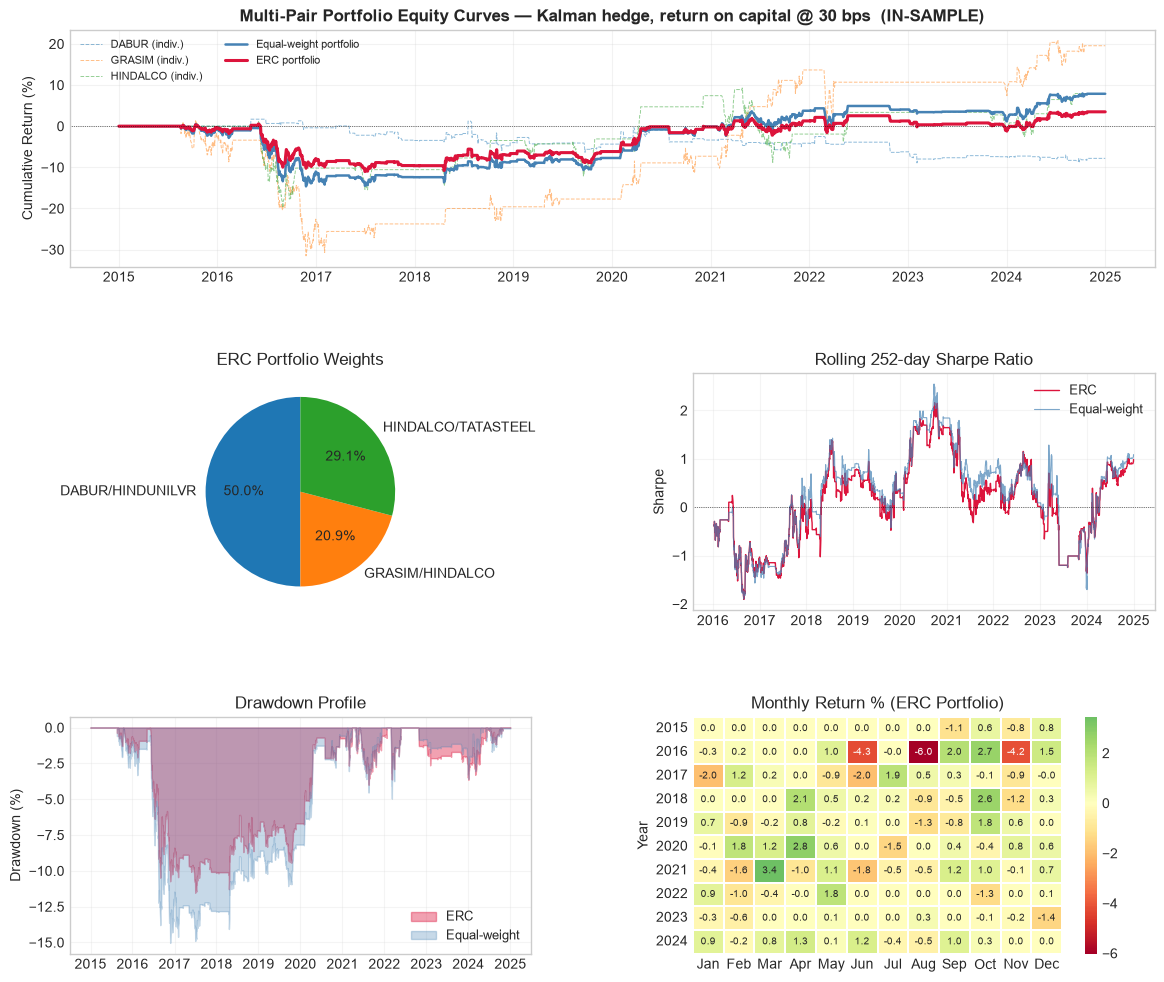

In [9]:
# Portfolio daily returns at the base cost level
pnl_equal = ret_df @ w_equal
pnl_erc   = ret_df @ w_erc

cum_equal = (1 + pnl_equal).cumprod() - 1
cum_erc   = (1 + pnl_erc  ).cumprod() - 1
cum_individuals = {col: (1 + ret_df[col]).cumprod() - 1 for col in ret_df.columns}

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.35)

# ── Main equity curve (return on capital, bounded) ───────────────────────
ax1 = fig.add_subplot(gs[0, :])
for label, cum_i in cum_individuals.items():
    short = label.split('/')[0].strip().replace('.NS', '')
    ax1.plot(cum_i * 100, linewidth=0.7, alpha=0.5, linestyle='--', label=f'{short} (indiv.)')
ax1.plot(cum_equal * 100, color='steelblue', linewidth=1.8, label='Equal-weight portfolio')
ax1.plot(cum_erc   * 100, color='crimson',   linewidth=2.2, label='ERC portfolio')
ax1.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax1.set_title(f'Multi-Pair Portfolio Equity Curves — Kalman hedge, return on capital '
              f'@ {BASE_COST} bps  (IN-SAMPLE)', fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(alpha=0.25)

# ── ERC weights pie ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
short_labels_pie = [c.split('/')[0].strip().replace('.NS', '') + '/' +
                    c.split('/')[1].strip().replace('.NS', '') for c in ret_df.columns]
ax2.pie(w_erc, labels=short_labels_pie, autopct='%1.1f%%', startangle=90)
ax2.set_title('ERC Portfolio Weights')

# ── Rolling 252d Sharpe (full window series) ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
roll_sh_erc = pnl_erc.rolling(252).apply(
    lambda r: r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan)
roll_sh_eq  = pnl_equal.rolling(252).apply(
    lambda r: r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan)
ax3.plot(roll_sh_erc, color='crimson',  linewidth=1.0, label='ERC')
ax3.plot(roll_sh_eq,  color='steelblue', linewidth=0.8, alpha=0.7, label='Equal-weight')
ax3.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax3.set_title('Rolling 252-day Sharpe Ratio')
ax3.set_ylabel('Sharpe'); ax3.legend(fontsize=9); ax3.grid(alpha=0.2)

# ── Drawdown ────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
def dd_curve(r):
    c = (1 + r).cumprod()
    return (c - c.cummax()) / c.cummax() * 100
ax4.fill_between(pnl_erc.index,   dd_curve(pnl_erc),   0, alpha=0.4, color='crimson',   label='ERC')
ax4.fill_between(pnl_equal.index, dd_curve(pnl_equal), 0, alpha=0.3, color='steelblue', label='Equal-weight')
ax4.set_title('Drawdown Profile'); ax4.set_ylabel('Drawdown (%)')
ax4.legend(fontsize=9); ax4.grid(alpha=0.2)

# ── Monthly P&L heatmap for ERC ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
monthly_df = (pnl_erc.resample('ME').sum() * 100).to_frame('pnl')
monthly_df['Year']  = monthly_df.index.year
monthly_df['Month'] = monthly_df.index.month
try:
    pivot = monthly_df.pivot(index='Year', columns='Month', values='pnl')
    pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:pivot.shape[1]]
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
                ax=ax5, linewidths=0.3, annot_kws={'size': 7})
    ax5.set_title('Monthly Return % (ERC Portfolio)')
except Exception:
    ax5.set_visible(False)

plt.savefig('portfolio_equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
def perf_stats(ret, label):
    """Performance of a daily return-on-capital series. Sharpe over the FULL
    series (config.sharpe_ratio); drawdown guarded (config.max_drawdown).
    'Active %' = share of days with non-zero P&L or cost (broader than the
    per-pair 'TiM%' above, which counts only days a position is actually held)."""
    r      = pd.Series(ret)
    ann_r  = r.mean() * 252
    ann_v  = r.std() * np.sqrt(252)
    mdd    = max_drawdown(r)                       # % (negative)
    active = r[r != 0]
    return pd.Series({
        'Ann Return %': round(ann_r * 100, 2),
        'Ann Vol %':    round(ann_v * 100, 2),
        'Sharpe':       round(sharpe_ratio(r), 3),
        'Max DD %':     round(mdd, 2),
        'Calmar':       round(ann_r / abs(mdd / 100), 3) if mdd != 0 else np.nan,
        'Active %':     round((r != 0).mean() * 100, 1),
        'Hit %':        round((active > 0).mean() * 100, 1) if len(active) else np.nan,
    }, name=label)

def short(c):
    return c.split('/')[0].strip().replace('.NS', '') + '/' + c.split('/')[1].strip().replace('.NS', '')

div_ratios = {}
for cost in COST_LEVELS:
    rd = ret_by_cost[cost]
    pe = rd @ w_equal
    pc = rd @ w_erc
    rows = [perf_stats(rd[c], short(c)) for c in rd.columns]
    rows.append(perf_stats(pe, 'EQUAL-WEIGHT PORTFOLIO'))
    rows.append(perf_stats(pc, 'ERC PORTFOLIO'))
    summary = pd.DataFrame(rows)

    indiv_vols = np.array([rd[c].std() * np.sqrt(252) for c in rd.columns])
    dr_erc   = (w_erc   @ indiv_vols) / (pc.std() * np.sqrt(252))
    dr_equal = (w_equal @ indiv_vols) / (pe.std() * np.sqrt(252))
    div_ratios[cost] = (dr_erc, dr_equal)

    print('=' * 82)
    print(f'  FINAL PERFORMANCE SUMMARY  @ {cost} bps round trip   (IN-SAMPLE, full 2015-2024)')
    print('=' * 82)
    print(summary.to_string())
    print(f'  Diversification ratio  ERC {dr_erc:.3f}  |  Equal-weight {dr_equal:.3f}   '
          '(>1 => portfolio vol below weighted-avg leg vol)\n')

print('ERC weights are held fixed across cost levels (fitted once on '
      f'{BASE_COST} bps returns); only the P&L is re-costed.')

  FINAL PERFORMANCE SUMMARY  @ 10 bps round trip   (IN-SAMPLE, full 2015-2024)
                        Ann Return %  Ann Vol %  Sharpe  Max DD %  Calmar  Active %  Hit %
DABUR/HINDUNILVR                1.24       3.79   0.326     -5.66   0.219       9.9   34.3
GRASIM/HINDALCO                 2.85      10.37   0.275    -32.25   0.088      28.6   48.7
HINDALCO/TATASTEEL              1.48       7.87   0.187    -20.77   0.071      21.7   48.4
EQUAL-WEIGHT PORTFOLIO          1.85       4.92   0.377    -14.52   0.128      45.9   47.9
ERC PORTFOLIO                   1.64       3.97   0.414    -10.62   0.155      45.9   47.5
  Diversification ratio  ERC 1.600  |  Equal-weight 1.492   (>1 => portfolio vol below weighted-avg leg vol)

  FINAL PERFORMANCE SUMMARY  @ 30 bps round trip   (IN-SAMPLE, full 2015-2024)
                        Ann Return %  Ann Vol %  Sharpe  Max DD %  Calmar  Active %  Hit %
DABUR/HINDUNILVR               -0.76       3.67  -0.208    -10.44  -0.073       9.9   30.2
GRAS

## Conclusion

### Reading the tables
- Every metric is shown at **10 / 30 / 60 bps round trip**. Judge at 30–60 bps.
- Sharpe is over the **full daily series** (`config.sharpe_ratio`), comparable to NB09.
- **In-sample**, full 2015–2024 history. The out-of-sample read is NB09.
- Only **3 pairs** cleared NB08; two share the HINDALCO leg. Thin diversification, 3×3 covariance.

### Diagnostics (this pass)
- **3a — Kalman turnover:** `KF_DELTA = 1e-4` is **too fast for DABUR/HINDUNILVR**. Its β
  moves ~5× more per day than the metals pairs, which turns the innovation into white
  noise (lag-1 autocorr +0.02 vs +0.96), causing 98 whipsaw trades and a Sharpe that
  goes negative on cost. Same δ is fine for the two metals pairs. Not re-tuned — diagnosed.
- **3b — ERC:** the optimiser converged (obj ≈ 1e-7, 8 restarts agree). The ~10 pp
  risk-contribution deviation is the **cost of `PORT_MAX_WEIGHT = 0.50`** — unconstrained
  ERC wants DABUR/HINDUNILVR at ≈57%. Labelled "capped ERC" now, with the uncapped
  reference reported alongside.

### Method safeguards
- Pairs from NB08 (`data/top_pairs.csv`); missing file raises.
- One P&L model (`config.pair_backtest`, return on capital, `min(ret) > -1` asserted).
- One Z-score (`config.rolling_zscore`), one Kalman filter (`config.kalman_hedge`, shared with NB07).
- Guarded drawdown (`config.max_drawdown`).
- Costs swept 10 / 30 / 60 bps, all reported.

### Bottom line
With 3 pairs, one cost-toxic under the adaptive hedge, and an ERC cap that binds,
this is a **construction illustration, not a deployable book**.